In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pickle
import torch

In [2]:
# These are the real numbers from your 4 notebooks
# You ran these yourself — these are not made up

results = {
    'Factory 1 (FD001)': {
        'auc': 0.9704,
        'n_windows': 17731,
        'n_sensors': 14,
        'op_conditions': 1,
        'fault_modes': 1,
        'dataset': 'FD001'
    },
    'Factory 2 (FD002)': {
        'auc': 0.8925,
        'n_windows': 46219,
        'n_sensors': 19,
        'op_conditions': 6,
        'fault_modes': 1,
        'dataset': 'FD002'
    },
    'Factory 3 (FD003)': {
        'auc': 0.9811,
        'n_windows': 21820,
        'n_sensors': 16,
        'op_conditions': 1,
        'fault_modes': 2,
        'dataset': 'FD003'
    },
    'Factory 4 (FD004)': {
        'auc': 0.8354,
        'n_windows': 54028,
        'n_sensors': 19,
        'op_conditions': 6,
        'fault_modes': 2,
        'dataset': 'FD004'
    }
}

print("Results loaded for all 4 factories")
for name, r in results.items():
    print(f"  {name}: AUC = {r['auc']}")

Results loaded for all 4 factories
  Factory 1 (FD001): AUC = 0.9704
  Factory 2 (FD002): AUC = 0.8925
  Factory 3 (FD003): AUC = 0.9811
  Factory 4 (FD004): AUC = 0.8354


In [3]:
# Build a comparison table
df = pd.DataFrame(results).T
df = df[['dataset', 'op_conditions', 'fault_modes', 
         'n_sensors', 'n_windows', 'auc']]

df.columns = ['Dataset', 'Op Conditions', 'Fault Modes',
              'Useful Sensors', 'Training Windows', 'AUC-ROC']

print("=" * 70)
print("NON-IID PROOF TABLE")
print("=" * 70)
print(df.to_string())
print()
print("KEY OBSERVATION:")
print("Factories with 1 operating condition (FD001, FD003): AUC > 0.97")
print("Factories with 6 operating conditions (FD002, FD004): AUC < 0.90")
print()
print("CONCLUSION:")
print("Same model, same code, different data = different results.")
print("This proves the Non-IID problem is REAL across these factories.")
print("A single global model cannot serve all factories equally well.")
print("This is WHY we need Federated Learning with Adaptive Clustering.")

NON-IID PROOF TABLE
                  Dataset Op Conditions Fault Modes Useful Sensors Training Windows AUC-ROC
Factory 1 (FD001)   FD001             1           1             14            17731  0.9704
Factory 2 (FD002)   FD002             6           1             19            46219  0.8925
Factory 3 (FD003)   FD003             1           2             16            21820  0.9811
Factory 4 (FD004)   FD004             6           2             19            54028  0.8354

KEY OBSERVATION:
Factories with 1 operating condition (FD001, FD003): AUC > 0.97
Factories with 6 operating conditions (FD002, FD004): AUC < 0.90

CONCLUSION:
Same model, same code, different data = different results.
This proves the Non-IID problem is REAL across these factories.
A single global model cannot serve all factories equally well.
This is WHY we need Federated Learning with Adaptive Clustering.


## AUC comparison bar chart

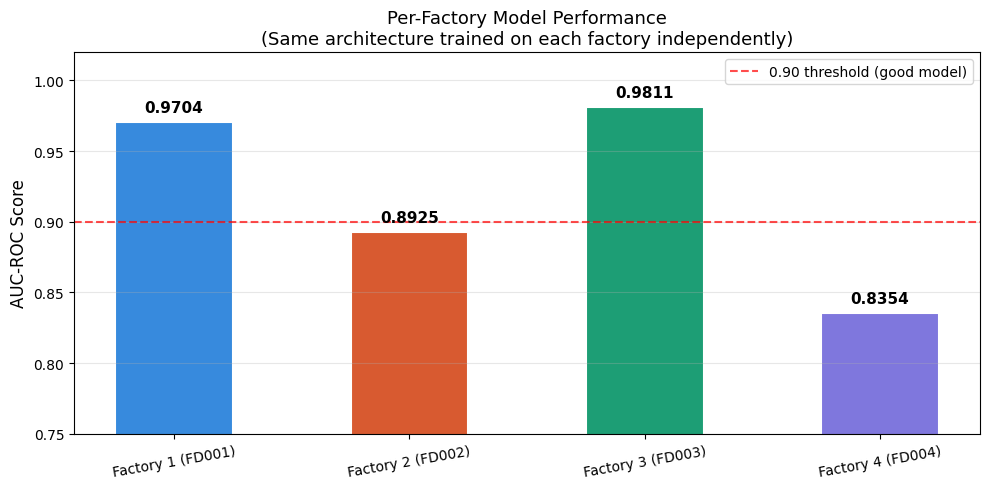

Chart saved as chart_auc_comparison.png


In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

factories = list(results.keys())
aucs = [results[f]['auc'] for f in factories]
colors = ['#378ADD', '#D85A30', '#1D9E75', '#7F77DD']

bars = ax.bar(factories, aucs, color=colors, width=0.5, 
              edgecolor='white', linewidth=1.5)

# Add value labels on top of each bar
for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{auc:.4f}', ha='center', va='bottom', 
            fontsize=11, fontweight='bold')

# Add a horizontal line at 0.90 — the "good enough" threshold
ax.axhline(y=0.90, color='red', linestyle='--', alpha=0.7, 
           label='0.90 threshold (good model)')

ax.set_ylim(0.75, 1.02)
ax.set_ylabel('AUC-ROC Score', fontsize=12)
ax.set_title('Per-Factory Model Performance\n(Same architecture trained on each factory independently)',
             fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig('chart_auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as chart_auc_comparison.png")

## Operating conditions vs AUC scatter

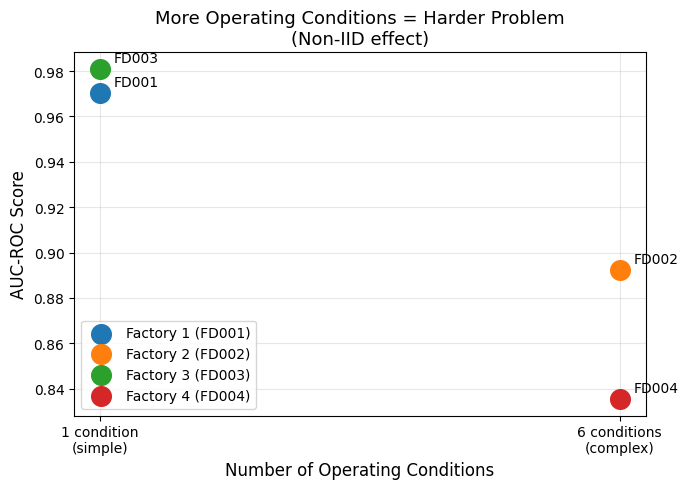

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))

for name, r in results.items():
    ax.scatter(r['op_conditions'], r['auc'], 
               s=200, zorder=5,
               label=name)
    ax.annotate(r['dataset'], 
                (r['op_conditions'], r['auc']),
                textcoords='offset points',
                xytext=(10, 5), fontsize=10)

ax.set_xlabel('Number of Operating Conditions', fontsize=12)
ax.set_ylabel('AUC-ROC Score', fontsize=12)
ax.set_title('More Operating Conditions = Harder Problem\n(Non-IID effect)',
             fontsize=13)
ax.set_xticks([1, 6])
ax.set_xticklabels(['1 condition\n(simple)', '6 conditions\n(complex)'])
ax.grid(alpha=0.3)
ax.legend(loc='lower left')

plt.tight_layout()
plt.savefig('chart_noniid_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Why this means clustering will work

In [6]:
print("=" * 60)
print("WHY ADAPTIVE CLUSTERING WILL HELP")
print("=" * 60)
print()
print("CLUSTER A (predicted):")
print("  Factory 1 (FD001) — 1 op condition, AUC 0.9704")
print("  Factory 3 (FD003) — 1 op condition, AUC 0.9811")
print("  → Similar data patterns, similar gradients")
print("  → Will train well together")
print()
print("CLUSTER B (predicted):")
print("  Factory 2 (FD002) — 6 op conditions, AUC 0.8925")
print("  Factory 4 (FD004) — 6 op conditions, AUC 0.8354")
print("  → Similar data patterns (both complex)")
print("  → Will train well together")
print()
print("WHAT CLUSTERING BUYS US:")
print("  Without clustering: one global model tries to serve all 4")
print("  → Average performance across all factories")
print()
print("  With clustering: Cluster A model specialises for simple factories")
print("                   Cluster B model specialises for complex factories")
print("  → Each factory gets a model tuned to its conditions")
print()
print("This is the core research hypothesis of the project.")
print("The FL system will verify this automatically.")

WHY ADAPTIVE CLUSTERING WILL HELP

CLUSTER A (predicted):
  Factory 1 (FD001) — 1 op condition, AUC 0.9704
  Factory 3 (FD003) — 1 op condition, AUC 0.9811
  → Similar data patterns, similar gradients
  → Will train well together

CLUSTER B (predicted):
  Factory 2 (FD002) — 6 op conditions, AUC 0.8925
  Factory 4 (FD004) — 6 op conditions, AUC 0.8354
  → Similar data patterns (both complex)
  → Will train well together

WHAT CLUSTERING BUYS US:
  Without clustering: one global model tries to serve all 4
  → Average performance across all factories

  With clustering: Cluster A model specialises for simple factories
                   Cluster B model specialises for complex factories
  → Each factory gets a model tuned to its conditions

This is the core research hypothesis of the project.
The FL system will verify this automatically.


## Save the comparison results

In [7]:
import json

comparison = {
    'FD001': {'auc': 0.9704, 'op_conditions': 1, 'fault_modes': 1},
    'FD002': {'auc': 0.8925, 'op_conditions': 6, 'fault_modes': 1},
    'FD003': {'auc': 0.9811, 'op_conditions': 1, 'fault_modes': 2},
    'FD004': {'auc': 0.8354, 'op_conditions': 6, 'fault_modes': 2},
}

with open('comparison_results.json', 'w') as f:
    json.dump(comparison, f, indent=2)

print("Saved comparison_results.json")
print()
print("Files you now have:")
print("  chart_auc_comparison.png  ← goes into your project report")
print("  chart_noniid_scatter.png  ← goes into your project report")
print("  comparison_results.json   ← gets read by the dashboard later")

Saved comparison_results.json

Files you now have:
  chart_auc_comparison.png  ← goes into your project report
  chart_noniid_scatter.png  ← goes into your project report
  comparison_results.json   ← gets read by the dashboard later
